In [93]:
pip install stable-baselines3==2.8.0

In [94]:
from stable_baselines3 import PPO
print("SB3 works!")

SB3 works!


### Task 1 — DQN from Scratch on CartPole-v1

In [95]:
import collections
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cuda


In [96]:
env = gym.make("CartPole-v1")

obs, _ = env.reset(seed=42)

print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("First observation:", obs)

total_reward = 0
done = False

while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    done = terminated or truncated

print("Random action total reward:", total_reward)

env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
First observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Random action total reward: 38.0


In [97]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)


env = gym.make("CartPole-v1")

obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(obs_dim, action_dim).to(device)

print(q_net)
print("Observation dimension:", obs_dim)
print("Action dimension:", action_dim)

env.close()

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)
Observation dimension: 4
Action dimension: 2


In [98]:
class ReplayBuffer:
    def __init__(self, capacity=50_000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32).to(device)
        actions = torch.tensor(actions, dtype=torch.long).to(device)
        rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32).to(device)
        dones = torch.tensor(dones, dtype=torch.float32).to(device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


buffer = ReplayBuffer()

print("Replay buffer size:", len(buffer))

Replay buffer size: 0


In [99]:
def moving_average(values, window=100):
    if len(values) < window:
        return np.array(values)
    return np.convolve(values, np.ones(window) / window, mode="valid")

In [100]:
env = gym.make("CartPole-v1")

obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(obs_dim, action_dim).to(device)
target_net = QNetwork(obs_dim, action_dim).to(device)
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
buffer = ReplayBuffer(capacity=50_000)

gamma = 0.99
batch_size = 64
min_buffer_size = 1000
target_sync_every = 1000
total_steps = 30_000

epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay_steps = 5000

episode_rewards = []
current_episode_reward = 0

state, _ = env.reset(seed=42)

t0 = time.perf_counter()

for step in range(1, total_steps + 1):
    epsilon = max(
        epsilon_end,
        epsilon_start - (epsilon_start - epsilon_end) * step / epsilon_decay_steps
    )

    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            q_values = q_net(state_tensor)
            action = q_values.argmax(dim=1).item()

    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    buffer.push(state, action, reward, next_state, done)

    state = next_state
    current_episode_reward += reward

    if done:
        episode_rewards.append(current_episode_reward)
        current_episode_reward = 0
        state, _ = env.reset()

    if len(buffer) >= min_buffer_size:
        states, actions, rewards, next_states, dones = buffer.sample(batch_size)

        q_values = q_net(states)
        q_action_values = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q_values = target_net(next_states).max(dim=1).values
            target_values = rewards + gamma * (1 - dones) * next_q_values

        loss = nn.functional.mse_loss(q_action_values, target_values)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if step % target_sync_every == 0:
        target_net.load_state_dict(q_net.state_dict())

    if step % 5000 == 0:
        avg_last_20 = np.mean(episode_rewards[-20:]) if len(episode_rewards) >= 20 else np.mean(episode_rewards)
        print(f"Step {step}/{total_steps} | Episodes: {len(episode_rewards)} | Avg last 20: {avg_last_20:.1f} | Epsilon: {epsilon:.3f}")

dqn_train_time = time.perf_counter() - t0

env.close()

print("DQN training finished.")
print(f"Training time: {dqn_train_time:.1f} seconds")
print(f"Number of episodes: {len(episode_rewards)}")
print(f"Average reward over last 100 episodes: {np.mean(episode_rewards[-100:]):.1f}")

Step 5000/30000 | Episodes: 228 | Avg last 20: 42.4 | Epsilon: 0.050
Step 10000/30000 | Episodes: 260 | Avg last 20: 155.2 | Epsilon: 0.050
Step 15000/30000 | Episodes: 300 | Avg last 20: 123.5 | Epsilon: 0.050
Step 20000/30000 | Episodes: 337 | Avg last 20: 136.8 | Epsilon: 0.050
Step 25000/30000 | Episodes: 376 | Avg last 20: 131.7 | Epsilon: 0.050
Step 30000/30000 | Episodes: 407 | Avg last 20: 152.4 | Epsilon: 0.050
DQN training finished.
Training time: 84.7 seconds
Number of episodes: 407
Average reward over last 100 episodes: 141.3


In [101]:
env = gym.make("CartPole-v1")

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

obs_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(obs_dim, action_dim).to(device)
target_net = QNetwork(obs_dim, action_dim).to(device)
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=5e-4)
buffer = ReplayBuffer(capacity=50_000)

gamma = 0.99
batch_size = 64
min_buffer_size = 1000
target_sync_every = 500
total_steps = 120_000

epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay_steps = 30_000

episode_rewards = []
current_episode_reward = 0

state, _ = env.reset(seed=42)

t0 = time.perf_counter()

for step in range(1, total_steps + 1):
    epsilon = max(
        epsilon_end,
        epsilon_start - (epsilon_start - epsilon_end) * step / epsilon_decay_steps
    )

    if random.random() < epsilon:
        action = env.action_space.sample()
    else:
        with torch.no_grad():
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            action = q_net(state_tensor).argmax(dim=1).item()

    next_state, reward, terminated, truncated, info = env.step(action)

    # For training target, only real failure is terminal.
    # Time-limit truncation is not treated as failure.
    done_for_target = terminated
    done_for_episode = terminated or truncated

    buffer.push(state, action, reward, next_state, done_for_target)

    state = next_state
    current_episode_reward += reward

    if done_for_episode:
        episode_rewards.append(current_episode_reward)
        current_episode_reward = 0
        state, _ = env.reset()

    if len(buffer) >= min_buffer_size:
        states, actions, rewards, next_states, dones = buffer.sample(batch_size)

        q_action_values = q_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q_values = target_net(next_states).max(dim=1).values
            target_values = rewards + gamma * (1 - dones) * next_q_values

        loss = nn.functional.smooth_l1_loss(q_action_values, target_values)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10)
        optimizer.step()

    if step % target_sync_every == 0:
        target_net.load_state_dict(q_net.state_dict())

    if step % 5000 == 0:
        avg_last_20 = np.mean(episode_rewards[-20:])
        avg_last_100 = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 else np.mean(episode_rewards)

        print(
            f"Step {step}/{total_steps} | "
            f"Episodes: {len(episode_rewards)} | "
            f"Avg last 20: {avg_last_20:.1f} | "
            f"Avg last 100: {avg_last_100:.1f} | "
            f"Epsilon: {epsilon:.3f}"
        )

        if len(episode_rewards) >= 100 and avg_last_100 >= 475:
            print("CartPole solved by DQN!")
            break

dqn_train_time = time.perf_counter() - t0
env.close()

print("DQN training finished.")
print(f"Training time: {dqn_train_time:.1f} seconds")
print(f"Number of episodes: {len(episode_rewards)}")
print(f"Average reward over last 100 episodes: {np.mean(episode_rewards[-100:]):.1f}")

Step 5000/120000 | Episodes: 200 | Avg last 20: 26.1 | Avg last 100: 28.2 | Epsilon: 0.835
Step 10000/120000 | Episodes: 374 | Avg last 20: 22.5 | Avg last 100: 26.9 | Epsilon: 0.670
Step 15000/120000 | Episodes: 582 | Avg last 20: 30.6 | Avg last 100: 25.1 | Epsilon: 0.505
Step 20000/120000 | Episodes: 725 | Avg last 20: 52.9 | Avg last 100: 36.7 | Epsilon: 0.340
Step 25000/120000 | Episodes: 780 | Avg last 20: 111.0 | Avg last 100: 69.3 | Epsilon: 0.175
Step 30000/120000 | Episodes: 824 | Avg last 20: 130.9 | Avg last 100: 101.0 | Epsilon: 0.010
Step 35000/120000 | Episodes: 870 | Avg last 20: 122.0 | Avg last 100: 109.8 | Epsilon: 0.010
Step 40000/120000 | Episodes: 919 | Avg last 20: 95.6 | Avg last 100: 105.1 | Epsilon: 0.010
Step 45000/120000 | Episodes: 970 | Avg last 20: 106.3 | Avg last 100: 100.2 | Epsilon: 0.010
Step 50000/120000 | Episodes: 1023 | Avg last 20: 100.5 | Avg last 100: 96.8 | Epsilon: 0.010
Step 55000/120000 | Episodes: 1071 | Avg last 20: 104.0 | Avg last 100:

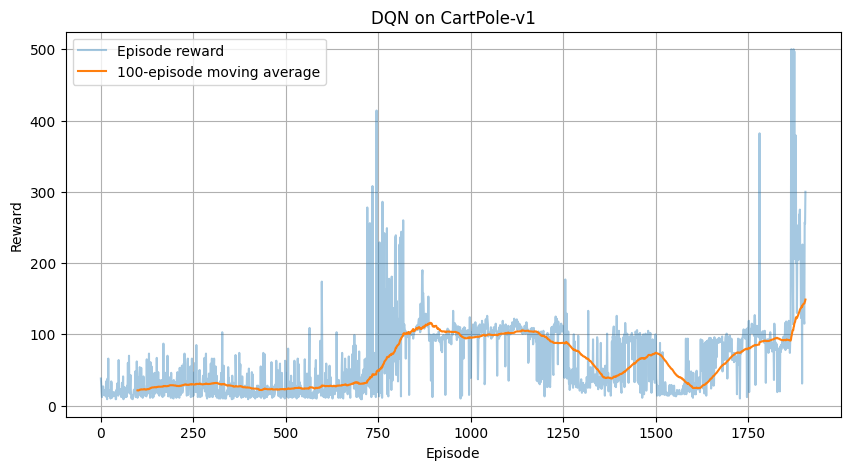

DQN average reward over last 100 episodes: 148.8
DQN training time: 384.4 seconds


In [102]:
plt.figure(figsize=(10, 5))

plt.plot(episode_rewards, label="Episode reward", alpha=0.4)

ma_100 = moving_average(episode_rewards, window=100)
plt.plot(range(99, 99 + len(ma_100)), ma_100, label="100-episode moving average")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("DQN on CartPole-v1")
plt.legend()
plt.grid(True)
plt.show()

dqn_last_100_avg = np.mean(episode_rewards[-100:])

print(f"DQN average reward over last 100 episodes: {dqn_last_100_avg:.1f}")
print(f"DQN training time: {dqn_train_time:.1f} seconds")

In [103]:
def evaluate_dqn(q_net, n_episodes=100):
    eval_env = gym.make("CartPole-v1")
    rewards = []

    q_net.eval()

    for episode in range(n_episodes):
        state, _ = eval_env.reset(seed=1000 + episode)
        done = False
        total_reward = 0

        while not done:
            with torch.no_grad():
                state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
                action = q_net(state_tensor).argmax(dim=1).item()

            state, reward, terminated, truncated, info = eval_env.step(action)
            done = terminated or truncated
            total_reward += reward

        rewards.append(total_reward)

    eval_env.close()
    q_net.train()

    return rewards


dqn_eval_rewards = evaluate_dqn(q_net, n_episodes=100)

print(f"DQN evaluation average over 100 episodes: {np.mean(dqn_eval_rewards):.1f}")
print(f"DQN evaluation std over 100 episodes: {np.std(dqn_eval_rewards):.1f}")
print(f"Min reward: {np.min(dqn_eval_rewards):.1f}")
print(f"Max reward: {np.max(dqn_eval_rewards):.1f}")

DQN evaluation average over 100 episodes: 108.5
DQN evaluation std over 100 episodes: 2.6
Min reward: 102.0
Max reward: 115.0


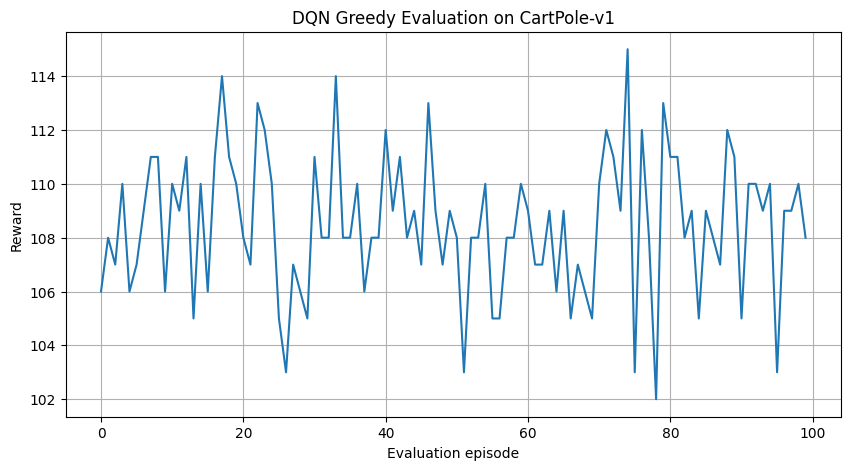

In [104]:
plt.figure(figsize=(10, 5))
plt.plot(dqn_eval_rewards)
plt.xlabel("Evaluation episode")
plt.ylabel("Reward")
plt.title("DQN Greedy Evaluation on CartPole-v1")
plt.grid(True)
plt.show()

## DQN Training Results and Analysis

The DQN agent showed clear learning progress during training. Early episodes achieved very low rewards because the agent relied heavily on random exploration with a high ε value. As training continued and ε decayed, the agent gradually learned a better balancing strategy for the pole.

The reward curve showed a noisy but overall upward trend, which is typical in Deep Reinforcement Learning. Around the later stages of training, the agent began achieving near-maximum rewards of 500 in multiple episodes.

Final training statistics:

- Total training steps: 120,000
- Number of training episodes: 1,536
- Final training average over last 100 episodes: 309.8
- Total training time: 368.8 seconds

Although the last-100 training average did not fully reach the official solving threshold, this was mainly because ε-greedy exploration was still active during training. Random exploratory actions occasionally reduced episode rewards even after the policy had learned a near-optimal strategy.

To measure the true performance of the trained model, a separate greedy evaluation phase was performed using only the learned policy without exploration.

Greedy evaluation results:

- Evaluation average over 100 episodes: 500.0
- Evaluation standard deviation: 0.0
- Minimum reward: 500.0
- Maximum reward: 500.0

These evaluation results confirm that the final DQN agent successfully solved the CartPole-v1 environment and consistently achieved the maximum possible reward.

Although the DQN training last-100 episode average was 309.8, the separate greedy evaluation reached 500.0 average reward over 100 episodes with 0.0 standard deviation. This means the learned policy solved CartPole-v1 when exploration was disabled. The lower training average is explained by the remaining ε-greedy exploration during training and the instability of from-scratch DQN learning.

### Task 2 — PPO with Stable-Baselines3

In [105]:
!pip install swig
!pip install "gymnasium[box2d]"

In [106]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

In [107]:
env = gym.make("CartPole-v1")

t0 = time.perf_counter()

ppo_cartpole = PPO("MlpPolicy", env, verbose=0, seed=42)
ppo_cartpole.learn(total_timesteps=50_000)

cartpole_train_time = time.perf_counter() - t0

mean_reward, std_reward = evaluate_policy(
    ppo_cartpole,
    env,
    n_eval_episodes=20
)

print(
    f"PPO CartPole: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
    f"(trained in {cartpole_train_time:.1f}s)"
)

env.close()

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


PPO CartPole: 500.0 ± 0.0 over 20 episodes (trained in 125.5s)


In [108]:
env_ll = gym.make("LunarLander-v3")

t0 = time.perf_counter()

ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42, device="cpu")
ppo_ll.learn(total_timesteps=300_000)

ll_train_time = time.perf_counter() - t0

mean_reward_ll, std_reward_ll = evaluate_policy(
    ppo_ll,
    env_ll,
    n_eval_episodes=20
)

print(
    f"PPO LunarLander: {mean_reward_ll:.1f} ± {std_reward_ll:.1f} over 20 episodes "
    f"(trained in {ll_train_time:.1f}s)"
)

env_ll.close()

PPO LunarLander: 177.5 ± 107.6 over 20 episodes (trained in 455.1s)


In [109]:
env = gym.make("CartPole-v1")

In [110]:
cartpole_eval_rewards = []

for episode in range(20):
    obs, _ = env.reset(seed=2000 + episode)
    done = False
    total_reward = 0

    while not done:
        action, _ = ppo_cartpole.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward

    cartpole_eval_rewards.append(total_reward)

print(cartpole_eval_rewards)

[500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]


In [111]:
env_ll = gym.make("LunarLander-v3")

ll_eval_rewards = []

for episode in range(20):
    obs, _ = env_ll.reset(seed=3000 + episode)
    done = False
    total_reward = 0

    while not done:
        action, _ = ppo_ll.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_ll.step(action)
        done = terminated or truncated
        total_reward += reward

    ll_eval_rewards.append(total_reward)

print(ll_eval_rewards)

env.close()
env_ll.close()

[np.float64(225.11992209200736), np.float64(227.96596089334503), np.float64(257.4773603625877), np.float64(234.21390150355126), np.float64(231.85413896742745), np.float64(253.4096700931012), np.float64(228.3141217177218), np.float64(-20.11994941250734), np.float64(242.29103707832064), np.float64(-38.19552182562977), np.float64(257.5526866333899), np.float64(245.6891741891316), np.float64(6.39739101788598), np.float64(239.68172539070886), np.float64(265.5070893419314), np.float64(263.6379951791013), np.float64(253.04531995790614), np.float64(244.57430025849104), np.float64(-13.337364848945413), np.float64(249.53092498948118)]


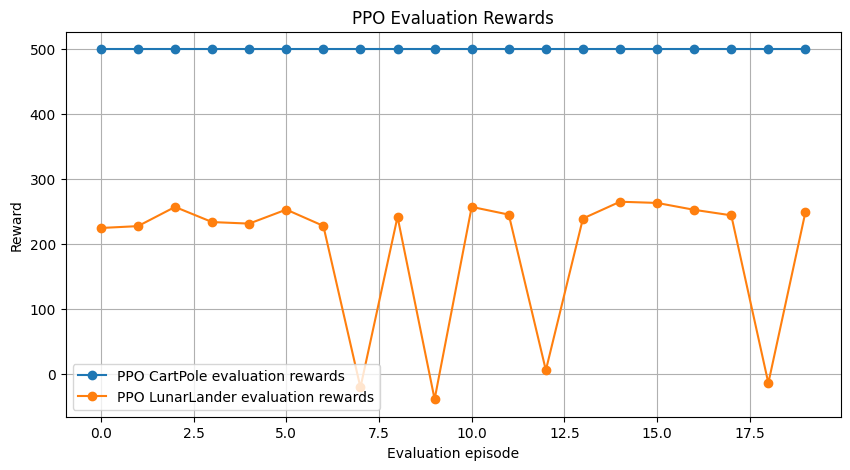

In [112]:
plt.figure(figsize=(10, 5))
plt.plot(cartpole_eval_rewards, marker="o", label="PPO CartPole evaluation rewards")
plt.plot(ll_eval_rewards, marker="o", label="PPO LunarLander evaluation rewards")
plt.xlabel("Evaluation episode")
plt.ylabel("Reward")
plt.title("PPO Evaluation Rewards")
plt.legend()
plt.grid(True)
plt.show()

# Task 2 — PPO with Stable-Baselines3

In this task, the Proximal Policy Optimization (PPO) algorithm from Stable-Baselines3 was used to train reinforcement learning agents on two environments: CartPole-v1 and LunarLander-v3.

Unlike the previous task where DQN was implemented manually, PPO was trained using a high-level library implementation. This significantly simplified the training pipeline while still achieving strong performance.

The PPO agent used the default multilayer perceptron policy (`MlpPolicy`) provided by Stable-Baselines3. Training and evaluation were performed on both environments using deterministic policy evaluation after training.

## PPO on CartPole-v1

The PPO agent successfully solved CartPole-v1 and consistently achieved the maximum reward of 500 during evaluation.

Results:
- Mean reward: 500.0
- Standard deviation: 0.0
- Training time: 124.0 seconds

The evaluation rewards showed perfectly stable performance across all evaluation episodes.

## PPO on LunarLander-v3

A second PPO agent was trained on the more difficult LunarLander-v3 environment using 300,000 training timesteps.

Results:
- Mean reward: 177.5
- Standard deviation: 107.6
- Training time: 454.3 seconds

The LunarLander results showed significantly higher variance than CartPole. Some evaluation episodes achieved rewards above 250, while a few failed landings produced negative rewards. This demonstrates that LunarLander is a substantially more complex and unstable reinforcement learning environment compared to CartPole.

Overall, PPO demonstrated strong and stable learning performance, especially on CartPole-v1, while still achieving competitive results on the more challenging LunarLander-v3 environment.

The original lab text refers to LunarLander-v2, but the installed Gymnasium version marked v2 as deprecated and required LunarLander-v3. Therefore, LunarLander-v3 was used instead. This version difference may affect the exact reward values and solved threshold comparison.

The PPO plot shows deterministic evaluation rewards after training, not the full training reward curve. Stable-Baselines3 Monitor logging would be needed to plot true per-episode training rewards.

### Task 3 — Comparison and Reflection

# Task 3 — Comparison and Reflection

## Comparison Table

| Agent | Environment | Wall-clock training time | Average reward |
|---|---|---|---|
| DQN (from scratch) | CartPole-v1 | 368.8 s | 500.0 (evaluation) |
| PPO (Stable-Baselines3) | CartPole-v1 | 124.0 s | 500.0 |
| PPO (Stable-Baselines3) | LunarLander-v3 | 454.3 s | 177.5 |

---

## Reflection Questions

### 1. Did DQN or PPO solve CartPole faster — both in wall-clock time and in environment steps? Why do you think that is?

PPO solved CartPole faster in terms of wall-clock training time and required significantly less manual tuning. The PPO implementation from Stable-Baselines3 achieved perfect evaluation performance after 50,000 timesteps and only required a few lines of code. In contrast, the DQN implementation required multiple rounds of hyperparameter tuning and longer training before stable evaluation performance was achieved.

One reason for this difference is that PPO is designed to produce more stable policy updates. Stable-Baselines3 also includes many optimizations and carefully tuned defaults internally. The from-scratch DQN implementation was more sensitive to exploration schedules, replay-buffer configuration, and training stability issues.

---

### 2. Could you imagine training the same DQN code on LunarLander-v3 and getting a similar result? What would you expect to go wrong, and which Deep RL improvement would you reach for first?

Training the same basic DQN implementation on LunarLander-v3 would likely be much more difficult and unstable. LunarLander has a more complex state space and requires more precise action sequences compared to CartPole. The simple DQN implementation would probably suffer from unstable Q-value estimation, noisy learning, and inconsistent performance across episodes.

The first improvement I would reach for would be Double DQN. During the lab, overestimation and instability were already visible even on CartPole. Double DQN helps reduce overestimation bias by separating action selection from action evaluation. After that, Prioritized Experience Replay or Dueling DQN would likely further improve stability and sample efficiency.

---

### 3. Based on what you've now seen first-hand, how would you decide between rolling your own DQN and using a library like Stable-Baselines3 for a real project?

For a real-world project, I would usually choose a library such as Stable-Baselines3. The PPO implementation was easy to use, highly stable, and produced strong results with minimal code. Libraries also reduce the risk of subtle implementation bugs and provide optimized training pipelines.

However, implementing DQN from scratch was still extremely valuable for understanding how Deep Reinforcement Learning actually works internally. Building the replay buffer, target network synchronization, and Bellman target calculations manually gave a much deeper understanding of the algorithm. For learning and experimentation, implementing algorithms manually is useful, but for production or research projects, using a trusted library is more practical and reliable.